In [1]:
import pandas as pd
import sqlite3

In [2]:
connect = sqlite3.connect('../../data/checking-logs.sqlite')


In [3]:
query = '''
SELECT uid, timestamp
FROM checker
WHERE uid LIKE 'user%'
'''
commits = pd.io.sql.read_sql(query, connect, parse_dates=['timestamp'])
commits['date'] = commits.timestamp.dt.date
commits['hour'] = commits.timestamp.dt.hour
commits

,uid,timestamp,date,hour
0,user_4,2020-04-17 05:19:02.744528,2020-04-17,5
1,user_4,2020-04-17 05:22:35.249331,2020-04-17,5
2,user_4,2020-04-17 05:22:45.549397,2020-04-17,5
3,user_4,2020-04-17 05:34:14.691200,2020-04-17,5
4,user_4,2020-04-17 05:34:24.422370,2020-04-17,5
...,...,...,...,...
3202,user_1,2020-05-21 20:19:06.872761,2020-05-21,20
3203,user_1,2020-05-21 20:22:41.785725,2020-05-21,20
3204,user_1,2020-05-21 20:22:41.877806,2020-05-21,20
3205,user_1,2020-05-21 20:37:00.129678,2020-05-21,20


In [4]:
commits['daytime'] = pd.cut(commits.hour,
                            bins = [0, 4, 10, 17, 24],
                            labels=['night', 'morning', 'afternoon', 'evening'],
                            right=False,
                            include_lowest=True)
commits

,uid,timestamp,date,hour,daytime
0,user_4,2020-04-17 05:19:02.744528,2020-04-17,5,morning
1,user_4,2020-04-17 05:22:35.249331,2020-04-17,5,morning
2,user_4,2020-04-17 05:22:45.549397,2020-04-17,5,morning
3,user_4,2020-04-17 05:34:14.691200,2020-04-17,5,morning
4,user_4,2020-04-17 05:34:24.422370,2020-04-17,5,morning
...,...,...,...,...,...
3202,user_1,2020-05-21 20:19:06.872761,2020-05-21,20,evening
3203,user_1,2020-05-21 20:22:41.785725,2020-05-21,20,evening
3204,user_1,2020-05-21 20:22:41.877806,2020-05-21,20,evening
3205,user_1,2020-05-21 20:37:00.129678,2020-05-21,20,evening


In [5]:
commits_group = commits.groupby('daytime').date.value_counts().unstack(0)
commits_group

/var/folders/_d/q8_c5ntn1zsdjh_6zk89_ch40000gn/T/ipykernel_2416/132162322.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  commits_group = commits.groupby('daytime').date.value_counts().unstack(0)


daytime,night,morning,afternoon,evening
date,,,,
2020-04-17,0,13,10,0
2020-04-18,0,1,33,35
2020-04-19,2,4,16,11
2020-04-20,0,0,12,13
2020-04-21,0,0,0,25
2020-04-22,0,0,4,24
2020-04-23,2,6,15,20
2020-04-24,0,0,4,12
2020-04-25,1,21,33,49


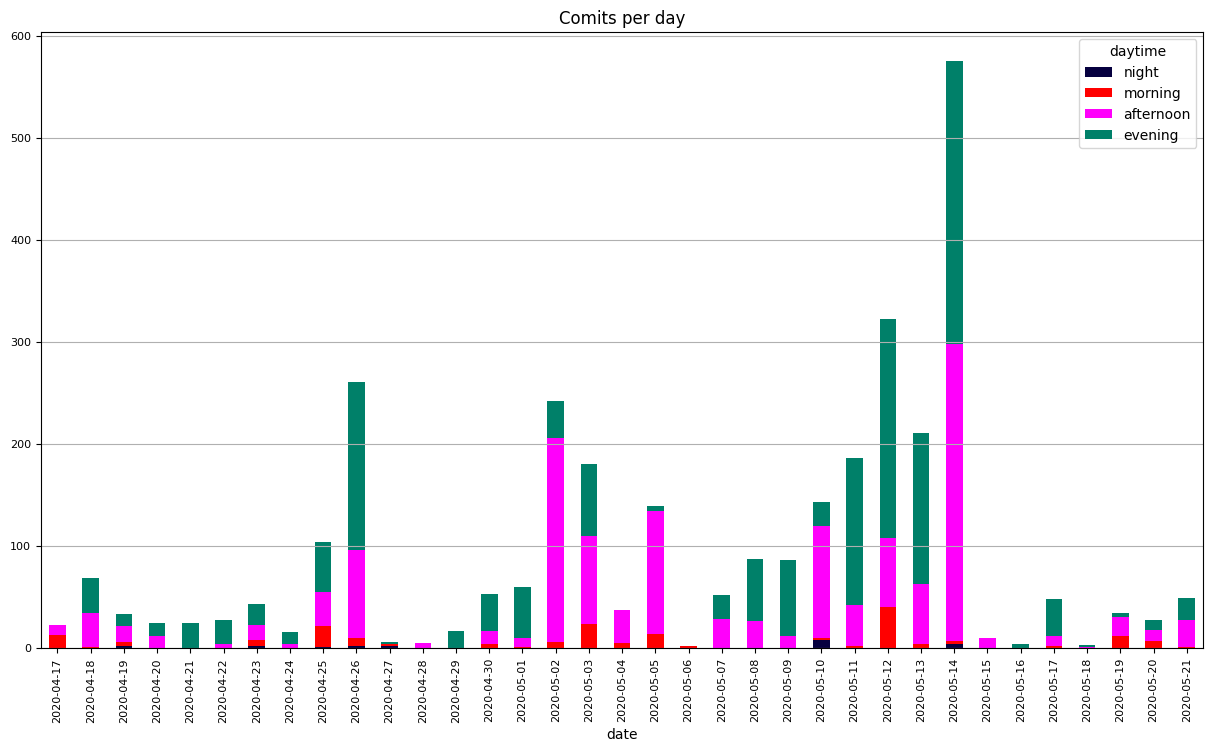

In [6]:
ax = commits_group.plot(kind='bar',
                        stacked=True,
                        figsize=(15,8),
                        title='Comits per day',
                        fontsize=8,
                        rot = 90,
                        color=["#06003f", "#ff0000", "#ff00fb", "#008069"])
ax.grid('on', which='major', axis='y')

In [7]:
commits_group.sum()


daytime
night          21
morning       184
afternoon    1391
evening      1611
dtype: int64

Днем и вечером два самых распространенных периода
Вечером больше всего

In [8]:
commits_group.loc[commits_group['evening'] > commits_group['afternoon']].sum(axis=1).idxmax()

datetime.date(2020, 5, 12)

ответ 12.05.2020

In [9]:
connect.close()